In [27]:
from time import time
import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor

from sklearn.linear_model import Ridge

from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR
from sklearn.svm import LinearSVR

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

In [28]:
def apply_style():
    plt.rcParams.update({
        'font.size': 14,
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 14,
        'lines.linewidth': 1.5,
        'lines.markersize': 4,
        'axes.linewidth': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'xtick.minor.visible': True,
        'ytick.minor.visible': True,
        'xtick.major.width': 1,
        'ytick.major.width': 1,
        'xtick.minor.width': 0.5,
        'ytick.minor.width': 0.5,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.minor.size': 1.5,
        'ytick.minor.size': 1.5,
        'legend.frameon': False,
        'legend.handlelength': 2,
        'legend.handletextpad': 0.5,
        'figure.dpi': 100,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,
    })

apply_style()

In [29]:
import inspect

def instantiate_model(model_class, random_state=42):
    if 'random_state' in inspect.signature(model_class.__init__).parameters:
        model = model_class(random_state=random_state)
    else:
        model = model_class()
    return model

def fit_model(model_class, X_train, y_train, random_state=42):
    ti = time()
    model = instantiate_model(model_class, random_state=random_state)
    model.fit(X_train, y_train)
    fit_time = time() - ti
    return model, fit_time

def evaluate_model(model, X, y_act):
    y_pred = model.predict(X)
    r2 = r2_score(y_act, y_pred)
    mae = mean_absolute_error(y_act, y_pred)
    rmse_val = root_mean_squared_error(y_act, y_pred)
    return r2, mae, rmse_val

def fit_evaluate_model(model_class, model_name, X_train, y_train, X_val, y_act_val, random_state=42):
    model, fit_time = fit_model(model_class, X_train, y_train, random_state=random_state)
    r2_train, mae_train, rmse_train = evaluate_model(model, X_train, y_train)
    r2_val, mae_val, rmse_val = evaluate_model(model, X_val, y_act_val)
    result_dict = {
        'model_name': model_name,
        'model_name_pretty': type(model).__name__,
        'model_params': model.get_params(),
        'fit_time': fit_time,
        'r2_train': r2_train,
        'mae_train': mae_train,
        'rmse_train': rmse_train,
        'r2_val': r2_val,
        'mae_val': mae_val,
        'rmse_val': rmse_val}
    return model, result_dict

def append_result_df(df, result_dict):
    df_result_appended = pd.concat([df, pd.DataFrame([result_dict])], ignore_index=True)
    return df_result_appended

def append_model_dict(dic, model_name, model):
    dic[model_name] = model
    return dic

In [30]:
df_train = pd.read_csv('regression_dataset_splits/app_train_split.csv')
df_test = pd.read_csv('regression_dataset_splits/app_test_split.csv')
df_val = pd.read_csv('regression_dataset_splits/app_val_split.csv')

In [31]:
df_train

,UID,Chemical,Time,Na,Cu,Fe,Mn,Ni,P2O3ratio,formula,...,var_gordy_en_max,var_gordy_en_range,var_gordy_en_mode,var_mb_en_sum,var_mb_en_avg,var_mb_en_dev,var_mb_en_min,var_mb_en_max,var_mb_en_range,var_mb_en_mode
0,U00006,NaCu0.5Mn0.5O2,12,1.0,0.500000,0.000000,0.500000,0.000000,1.00,NaCu0.5Mn0.5O2,...,0.298507,0.027073,0.271435,0.074112,0.074112,0.029336,0.044776,0.103448,0.058672,0.103448
1,U00008,NaFe0.5Mn0.5O2,12,1.0,0.000000,0.500000,0.500000,0.000000,1.00,NaFe0.5Mn0.5O2,...,0.266255,0.011477,0.266255,0.057325,0.057325,0.006369,0.050955,0.063694,0.012739,0.063694
2,U00010,NaMn0.5Ni0.5O2,12,1.0,0.000000,0.000000,0.500000,0.500000,1.00,NaMn0.5Ni0.5O2,...,0.298507,0.024911,0.273596,0.070581,0.070581,0.025805,0.044776,0.096386,0.051609,0.096386
3,U00013,NaCu1/3Mn1/3Ni1/3O2,12,1.0,0.333333,0.000000,0.333333,0.333333,1.00,NaCu1/3Mn1/3Ni1/3O2,...,0.306872,0.035437,0.271435,0.080859,0.080940,0.025826,0.044776,0.103448,0.058672,0.103448
4,U00014,NaFe1/3Mn1/3Ni1/3O2,12,1.0,0.000000,0.333333,0.333333,0.333333,0.00,NaFe1/3Mn1/3Ni1/3O2,...,0.298507,0.032253,0.266255,0.068217,0.068285,0.021318,0.044776,0.096386,0.051609,0.063694
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,U00363,Na0.5Cu1/9Mn8/27Fe8/27Ni8/27O2,3,0.5,0.111111,0.296296,0.296296,0.296296,0.45,Na0.5Cu1/9Mn8/27Fe8/27Ni8/27O2,...,0.366266,0.100012,0.266255,0.071966,0.072039,0.023632,0.000000,0.103448,0.103448,0.063694
180,U00364,Na0.5Fe7/18Ni7/18Cu1/9Mn1/9O2,3,0.5,0.111111,0.388889,0.111111,0.388889,0.18,Na0.5Fe7/18Ni7/18Cu1/9Mn1/9O2,...,0.366266,0.100012,0.266255,0.077218,0.077218,0.024388,0.000000,0.103448,0.103448,0.063694
181,U00367,Na0.5Cu7/18Fe7/18Mn1/9Ni1/9O2,3,0.5,0.388889,0.388889,0.111111,0.111111,0.00,Na0.5Cu7/18Fe7/18Mn1/9Ni1/9O2,...,0.366266,0.100012,0.271435,0.075760,0.075760,0.032264,0.000000,0.103448,0.103448,0.103448
182,U00368,Na0.5Mn7/18Ni7/18Fe1/9Cu1/9O2,3,0.5,0.111111,0.111111,0.388889,0.388889,0.83,Na0.5Mn7/18Ni7/18Fe1/9Cu1/9O2,...,0.366266,0.100012,0.298507,0.073252,0.073252,0.025014,0.044776,0.103448,0.058672,0.044776


In [32]:
df_train["target"] = df_train["P2O3ratio"]
df_val["target"]   = df_val["P2O3ratio"]
df_test["target"]  = df_test["P2O3ratio"]

/tmp/ipykernel_72176/2457951630.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train["target"] = df_train["P2O3ratio"]
/tmp/ipykernel_72176/2457951630.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_val["target"]   = df_val["P2O3ratio"]
/tmp/ipykernel_72176/2457951630.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented fram

In [33]:
# Define which columns are your features (drop non-numeric / target cols)
feature_cols = [col for col in df_train.columns if col not in ['UID','Chemical','P2O3ratio','target', 'formula', 'Cat_Success']]

# Training
X_train = df_train[feature_cols].values
y_train = df_train['target'].values

# Validation
X_val = df_val[feature_cols].values
y_val = df_val['target'].values

# Test
X_test = df_test[feature_cols].values
y_test = df_test['target'].values

In [34]:
# --- Distribution of pure O3 (0), pure P2 (1), and mixed-phase samples across splits ---

def categorize_phase(y):
    y = pd.Series(y).reset_index(drop=True)
    return pd.cut(y, bins=[-0.001, 0.001, 0.999, 1.001], labels=['Pure O3 (0)', 'Mixed', 'Pure P2 (1)'])

df_split_summary = pd.DataFrame({
    'train': categorize_phase(y_train).value_counts(),
    'val': categorize_phase(y_val).value_counts(),
    'test': categorize_phase(y_test).value_counts(),
})

# Add proportions (normalized within each split) alongside raw counts
df_split_proportions = df_split_summary.div(df_split_summary.sum(axis=0), axis=1).round(3)

print('Counts:')
print(df_split_summary)
print('\nProportions (within each split):')
print(df_split_proportions)

Counts:
             train  val  test
Pure P2 (1)     97   30    12
Mixed           66   18    11
Pure O3 (0)     21    5     3

Proportions (within each split):
             train    val   test
Pure P2 (1)  0.527  0.566  0.462
Mixed        0.359  0.340  0.423
Pure O3 (0)  0.114  0.094  0.115


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = normalize(X_train)
X_val = normalize(X_val)
X_test = normalize(X_test)

In [36]:
import inspect

df_classics = pd.DataFrame(columns=['model_name',
                                    'model_name_pretty',
                                    'model_params',
                                    'fit_time',
                                    'r2_train',
                                    'mae_train',
                                    'rmse_train',
                                    'r2_val',
                                    'mae_val',
                                    'rmse_val'])

classic_model_names = OrderedDict({
    'dumr': DummyRegressor,
    'rr': Ridge,
    'abr': AdaBoostRegressor,
    'gbr': GradientBoostingRegressor,
    'rfr': RandomForestRegressor,
    'etr': ExtraTreesRegressor, # this consistently overfits
    'svr': SVR,
    'lsvr': LinearSVR,
    'knr': KNeighborsRegressor,
})

RANDOM_STATE = 0

classic_models = OrderedDict()
ti = time()

for model_name, model_class in classic_model_names.items():
    print(f'Now fitting and evaluating model {model_name}: {model_class.__name__}')
    model, result_dict = fit_evaluate_model(model_class, model_name, X_train, y_train, X_val, y_val, random_state=RANDOM_STATE)
    df_classics = append_result_df(df_classics, result_dict)
    classic_models = append_model_dict(classic_models, model_name, model)

dt = time() - ti
print(f'Finished fitting {len(classic_models)} models, total time: {dt:0.2f} s')

Now fitting and evaluating model dumr: DummyRegressor
Now fitting and evaluating model rr: Ridge
Now fitting and evaluating model abr: AdaBoostRegressor
Now fitting and evaluating model gbr: GradientBoostingRegressor
Now fitting and evaluating model rfr: RandomForestRegressor
Now fitting and evaluating model etr: ExtraTreesRegressor
Now fitting and evaluating model svr: SVR
Now fitting and evaluating model lsvr: LinearSVR
Now fitting and evaluating model knr: KNeighborsRegressor
Finished fitting 9 models, total time: 2.51 s


/home/faytimen/Documents/Projects/ml_model_p2o3/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [37]:
# Sort in order of increasing validation r2 score
df_classics = df_classics.sort_values('r2_val', ignore_index=True)
df_classics

,model_name,model_name_pretty,model_params,fit_time,r2_train,mae_train,rmse_train,r2_val,mae_val,rmse_val
0,dumr,DummyRegressor,"{'constant': None, 'quantile': None, 'strategy...",0.000862,0.0,0.305533,0.362215,-0.003046,0.292028,0.343119
1,knr,KNeighborsRegressor,"{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.000419,0.59569,0.155174,0.230316,0.21627,0.216038,0.303296
2,svr,SVR,"{'C': 1.0, 'cache_size': 200, 'coef0': 0.0, 'd...",0.003345,0.69407,0.1321,0.200345,0.419202,0.218168,0.261094
3,rr,Ridge,"{'alpha': 1.0, 'copy_X': True, 'fit_intercept'...",0.003479,0.59019,0.172533,0.231877,0.503643,0.193169,0.241369
4,lsvr,LinearSVR,"{'C': 1.0, 'dual': 'auto', 'epsilon': 0.0, 'fi...",0.019482,0.549412,0.140038,0.24314,0.545938,0.171275,0.230856
5,abr,AdaBoostRegressor,"{'estimator': None, 'learning_rate': 1.0, 'los...",0.133834,0.842422,0.113473,0.143785,0.55073,0.1777,0.229635
6,etr,ExtraTreesRegressor,"{'bootstrap': False, 'ccp_alpha': 0.0, 'criter...",0.619117,1.0,0.0,0.0,0.668727,0.148474,0.197186
7,gbr,GradientBoostingRegressor,"{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': ...",0.681016,0.968007,0.045629,0.064788,0.675491,0.133246,0.195163
8,rfr,RandomForestRegressor,"{'bootstrap': True, 'ccp_alpha': 0.0, 'criteri...",0.915784,0.918141,0.063024,0.103633,0.695176,0.143953,0.189151


In [38]:
# Find the best-performing model that we have tested
best_row = df_classics.iloc[-1, :].copy()

# Get the model type and model parameters
model_name = best_row['model_name']
model_params = best_row['model_params']

# Instantiate the model again using the parameters
model = classic_model_names[model_name](**model_params)
print(model)

RandomForestRegressor(random_state=0)


Finished fitting best model, total time: 1.40 s

Test set        — r2: 0.2989, mae: 0.2047, rmse: 0.2877
Full dataset    — r2: 0.8675, mae: 0.0740, rmse: 0.1298



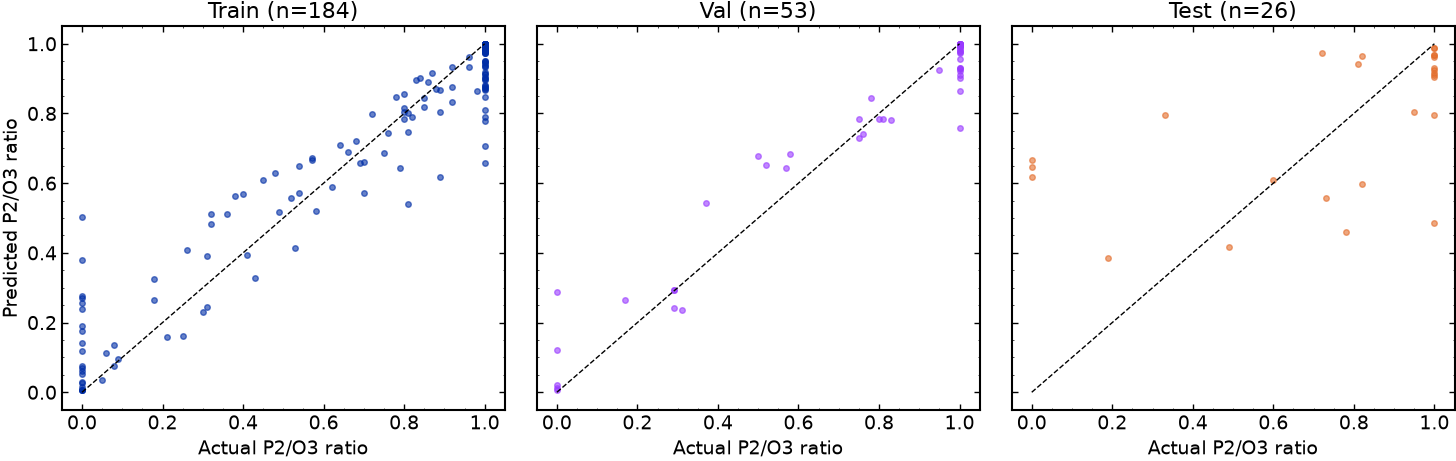

In [39]:
# Combine train+val for final fit, fit the model 
X_train_new = np.concatenate((X_train, X_val), axis=0)
y_train_new = pd.concat((pd.Series(y_train), pd.Series(y_val)), axis=0).reset_index(drop=True)

ti = time()
model.fit(X_train_new, y_train_new)
dt = time() - ti
print(f'Finished fitting best model, total time: {dt:0.2f} s\n')

# Evaluate on test set only (true held-out performance)
y_test_series = pd.Series(y_test).reset_index(drop=True)
r2_test, mae_test, rmse_test = evaluate_model(model, X_test, y_test_series)
print(f'Test set        — r2: {r2_test:0.4f}, mae: {mae_test:0.4f}, rmse: {rmse_test:0.4f}')

# Evaluate on full dataset (train+val+test combined)
X_full = np.concatenate((X_train, X_val, X_test), axis=0)
y_full = pd.concat((pd.Series(y_train), pd.Series(y_val), y_test_series), axis=0).reset_index(drop=True)

r2_full, mae_full, rmse_full = evaluate_model(model, X_full, y_full)
print(f'Full dataset    — r2: {r2_full:0.4f}, mae: {mae_full:0.4f}, rmse: {rmse_full:0.4f}\n')

# --- Predicted vs Actual plot, coloured by data split ---
y_pred_full = model.predict(X_full)

df_preds = pd.DataFrame({
    'actual': y_full.values,
    'predicted': y_pred_full,
    'split': (['train'] * len(y_train)) + (['val'] * len(y_val)) + (['test'] * len(y_test))
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

split_order = ['train', 'val', 'test']
split_colors = {'train': '#002ea6', 'val': '#993AFF', 'test': '#E36C2A'}

for ax, split_name in zip(axes, split_order):
    df_split = df_preds[df_preds['split'] == split_name]
    ax.scatter(df_split['actual'], df_split['predicted'], alpha=0.6, color=split_colors[split_name])
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)

    ax.set_xlabel('Actual P2/O3 ratio')
    ax.set_title(f'{split_name.capitalize()} (n={len(df_split)})')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

axes[0].set_ylabel('Predicted P2/O3 ratio')

plt.tight_layout()
plt.show()